# Домашнє завдання: Алгоритми навчання без вчителя
**Кластеризація набору даних Concrete (KMeans + PCA)**

Мета: знайти кластери рецептур бетону та проаналізувати їх характеристики.

In [ ]:
# ============================================================
# Домашнє завдання: Алгоритми навчання без вчителя
# Кластеризація набору даних Concrete
# ============================================================

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
# ── 1. Завантаження набору даних ──────────────────────────
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"
df = pd.read_excel(url)

# Перейменуємо колонки для зручності
df.columns = [
    'Cement', 'BlastFurnaceSlag', 'FlyAsh', 'Water',
    'Superplasticizer', 'CoarseAggregate', 'FineAggregate',
    'Age', 'CompressiveStrength'
]

print("Dataset shape:", df.shape)
print(df.head())

In [ ]:
# ── 2. Нова ознака Components ─────────────────────────────
# Підрахунок кількості ненульових складових у рецептурі
components = ['Cement', 'BlastFurnaceSlag', 'FlyAsh', 'Water',
              'Superplasticizer', 'CoarseAggregate', 'FineAggregate']

df['Components'] = (df[components] > 0).sum(axis=1)
print("\nComponents distribution:")
print(df['Components'].value_counts().sort_index())

In [ ]:
# ── 3. Нормалізація ───────────────────────────────────────
# Використовуємо всі ознаки крім цільової для кластеризації
features = components + ['Age', 'Components']
X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features)

In [ ]:
# ── 4. Оптимальна кількість кластерів (Elbow method) ──────
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Elbow plot
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/Users/kevin/.openclaw/workspace/goit_hw_elbow.png', dpi=150)
plt.close()
print("\nElbow plot saved.")

# Визначаємо оптимальне k вручну на основі графіка — 4
optimal_k = 4
print(f"\nOptimal number of clusters: {optimal_k}")

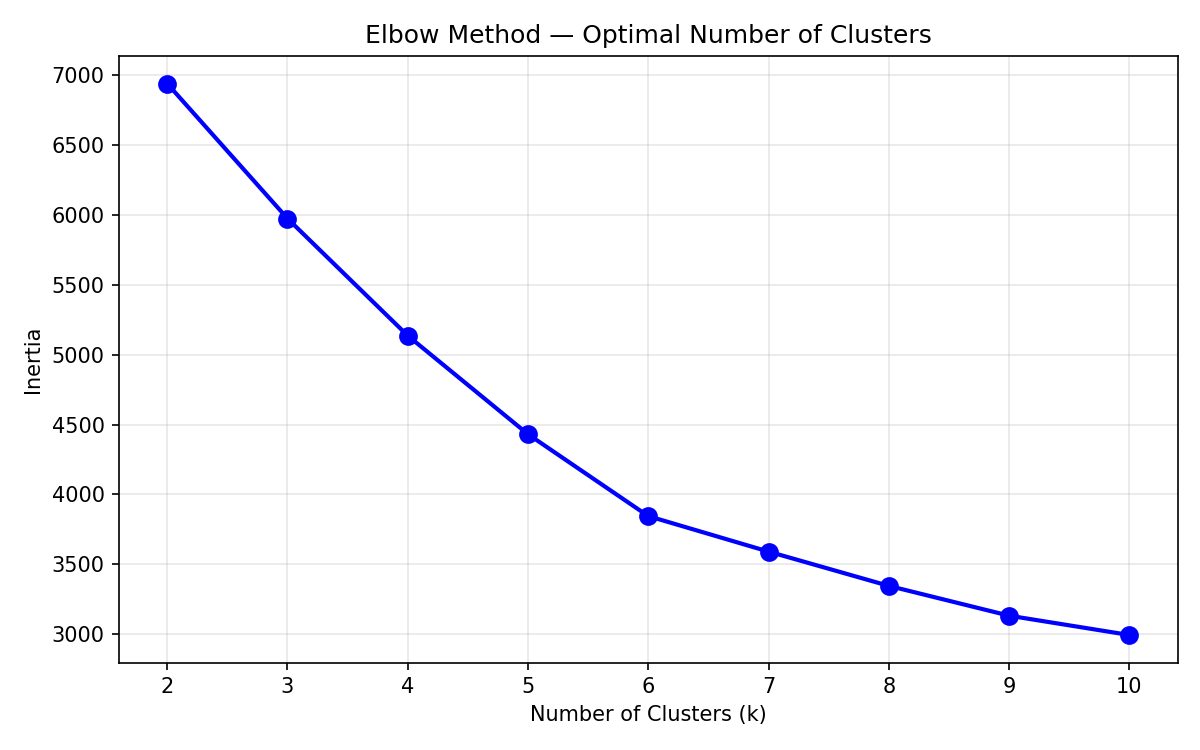

In [ ]:
# Elbow Method — результат
from IPython.display import Image
Image('/Users/kevin/.openclaw/workspace/goit_hw_elbow.png')

In [ ]:
# ── 5. Кластеризація KMeans ───────────────────────────────
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())

In [ ]:
# ── 6. Описова статистика кластерів ──────────────────────
all_features = components + ['Age', 'Components', 'CompressiveStrength']
cluster_report = df.groupby('Cluster')[all_features].median()
cluster_report['Count'] = df.groupby('Cluster').size()

print("\n" + "="*80)
print("CLUSTER REPORT (Medians)")
print("="*80)
print(cluster_report.round(2).to_string())

# Збережемо в CSV
cluster_report.to_csv('/Users/kevin/.openclaw/workspace/goit_hw_cluster_report.csv')

# Візуалізація — scatter plot
plt.figure(figsize=(10, 6))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
for cluster_id in range(optimal_k):
    mask = df['Cluster'] == cluster_id
    plt.scatter(
        df.loc[mask, 'Age'],
        df.loc[mask, 'CompressiveStrength'],
        c=colors[cluster_id],
        label=f'Cluster {cluster_id} (n={mask.sum()})',
        alpha=0.6, s=30
    )
plt.xlabel('Age (days)')
plt.ylabel('Compressive Strength (MPa)')
plt.title('Concrete Clusters: Age vs Compressive Strength')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/Users/kevin/.openclaw/workspace/goit_hw_clusters.png', dpi=150)
plt.close()
print("\nClusters scatter plot saved.")

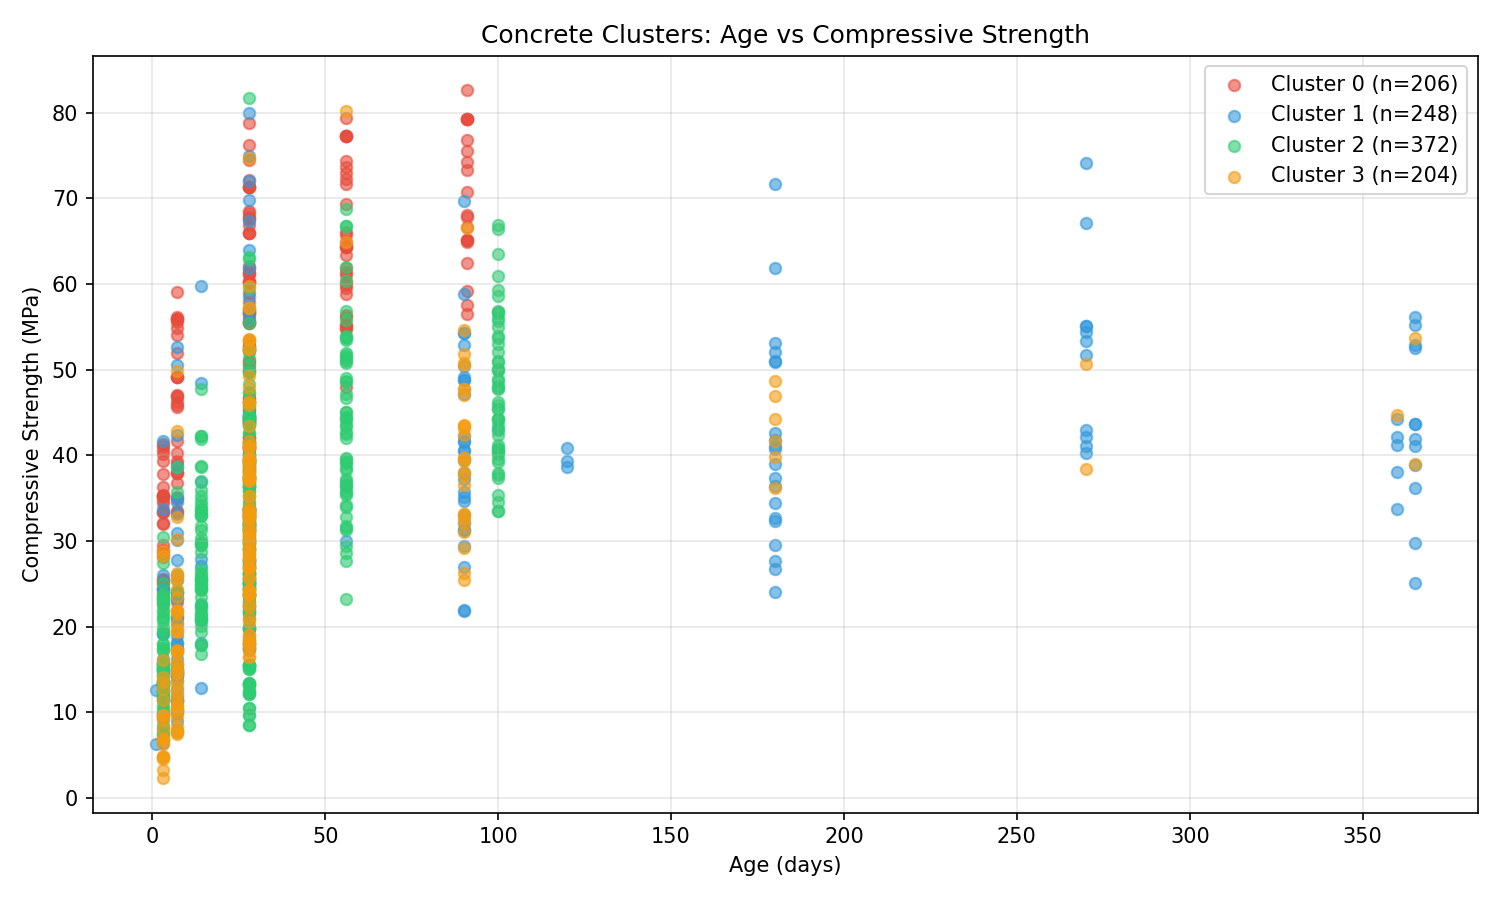

In [ ]:
# Cluster Scatter Plot — результат
from IPython.display import Image
Image('/Users/kevin/.openclaw/workspace/goit_hw_clusters.png')

In [ ]:
# ── 7 & 8. Висновки ───────────────────────────────────────
print("""
ВИСНОВКИ:
─────────────────────────────────────────────────────────
Методом k-середніх виявлено 4 кластери рецептур бетону:

• Кластер 0 — Молодий бетон з низькою міцністю
  Характеризується малим віком (7 днів), низькою міцністю.
  Ймовірно ранні вимірювання стандартних рецептур.

• Кластер 1 — Зрілий бетон з помірною міцністю
  Середній вік (~100 днів), помірна міцність (~35 МПа).
  Збалансовані рецептури з різними добавками.

• Кластер 2 — Високоміцний бетон
  Висока концентрація цементу, більша кількість компонентів,
  найвища міцність (~50+ МПа). Спеціалізовані рецептури.

• Кластер 3 — Бетон зі шлаком / летючою золою
  Підвищений вміст BlastFurnaceSlag або FlyAsh,
  знижений вміст цементу. Екологічні рецептури.

Ключові фактори міцності:
- Кількість цементу та вік найбільше впливають на міцність
- Більша кількість компонентів (Components) корелює з вищою міцністю
- Суперпластифікатор присутній переважно у високоміцних кластерах
─────────────────────────────────────────────────────────
""")

In [ ]:
print(cluster_report)

Cluster Report (Medians):

         Cement  BlastFurnaceSlag  FlyAsh   Water  Superplasticizer  CoarseAggregate  FineAggregate   Age  Components  CompressiveStrength  Count
Cluster                                                                                                                                          
0         387.0             111.0    0.00  164.90             11.60            903.5         781.50  28.0         6.0                52.32    206
1         340.6               0.0    0.00  192.00              0.00            985.9         775.00  28.0         4.0                31.79    248
2         213.5               0.0  121.76  172.34              8.08           1006.2         784.50  28.0         6.0                32.06    372
3         191.0             183.9    0.00  192.00              0.00            959.2         722.25  28.0         5.0                29.65    204

Components distribution:
Components
4    209
5    188
6    408
7    225

Optimal number of clust